MSE: 1519.8266403600503
RMSE: 38.98495402536792


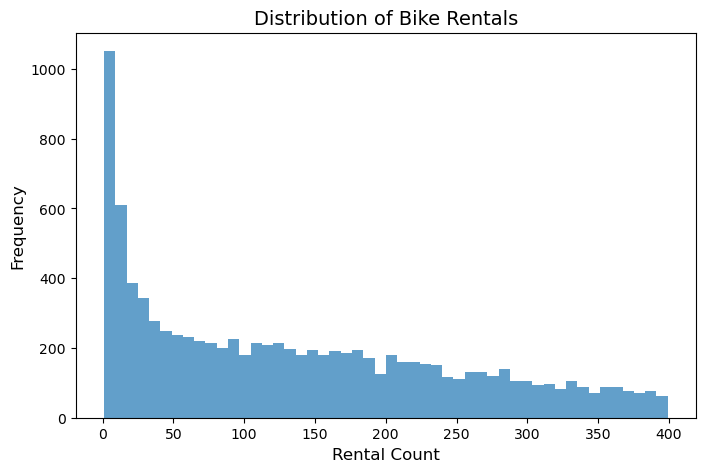

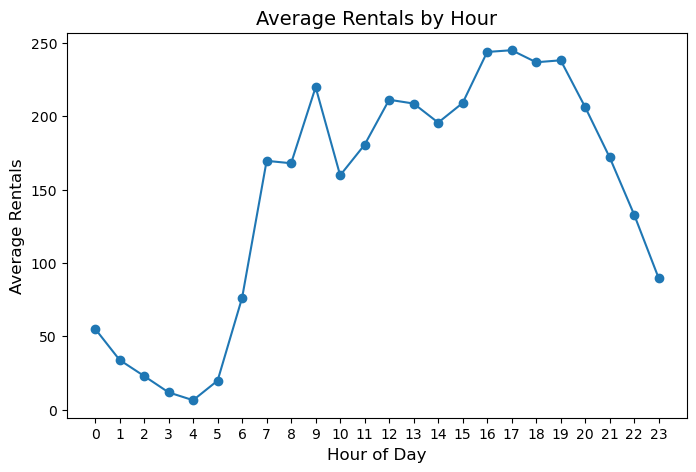

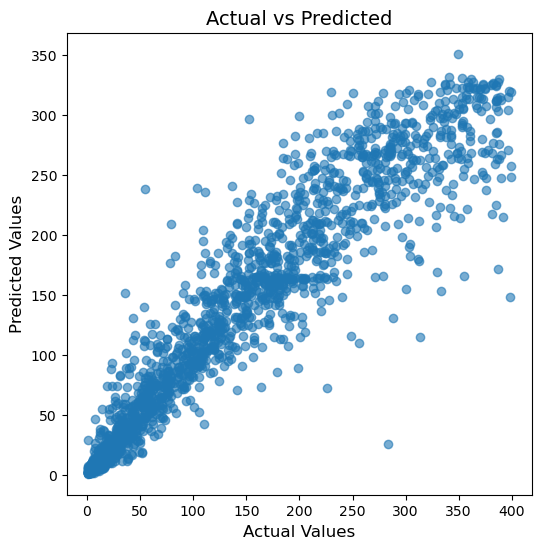

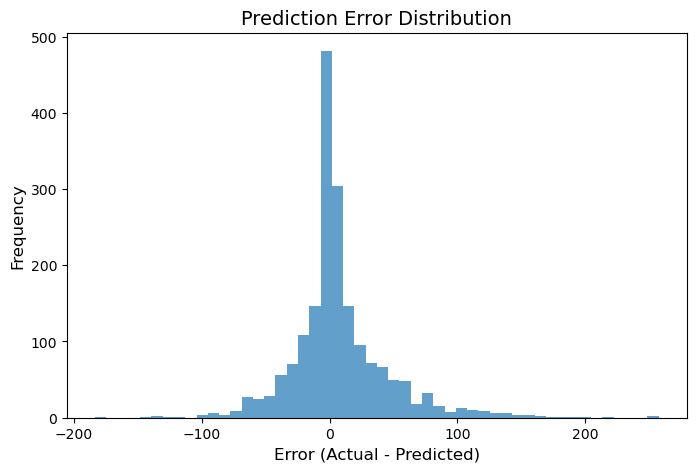

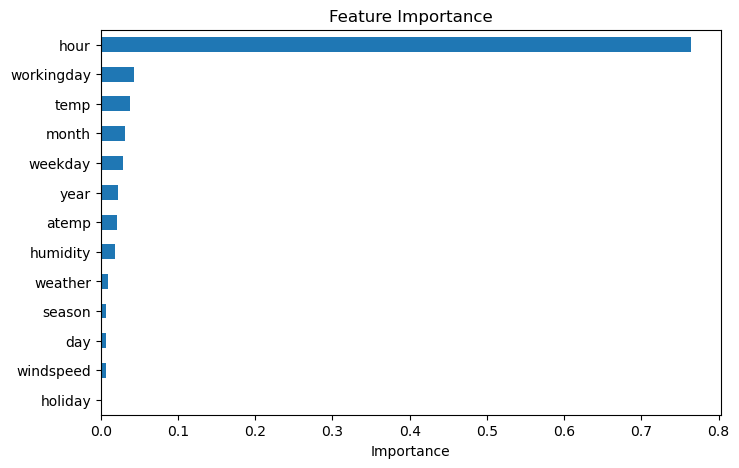

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv")

# 2. datetime 전처리
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday
train = train.drop(['datetime'], axis=1)

# 3. 이상치 제거
train = train[train['count'] < 400]

# 4. 로그 변환
y = np.log1p(train['count'])
X = train.drop(['count', 'casual', 'registered'], axis=1)

# 5. 데이터 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. 모델 학습
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 7. 예측
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# 8. 성능 평가
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test_real, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

# 시각화 1: 데이터 분포
plt.figure(figsize=(8, 5))
plt.hist(train['count'], bins=50, alpha=0.7)
plt.title("Distribution of Bike Rentals", fontsize=14)
plt.xlabel("Rental Count", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

# 시각화 2: 시간별 평균 대여량
plt.figure(figsize=(8, 5))
hourly_mean = train.groupby('hour')['count'].mean()
plt.plot(hourly_mean, marker='o')
plt.title("Average Rentals by Hour", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Rentals", fontsize=12)
plt.xticks(range(0, 24))
plt.show()

# 시각화 3: 실제값 vs 예측값
plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred, alpha=0.6)
plt.title("Actual vs Predicted", fontsize=14)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.show()

# 시각화 4: 오차 분포
errors = y_test_real - y_pred
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50, alpha=0.7)
plt.title("Prediction Error Distribution", fontsize=14)
plt.xlabel("Error (Actual - Predicted)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

# 시각화 5: Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()